In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score, roc_auc_score, roc_curve

In [4]:
df = pd.read_csv("Loan_Default_noisy.csv")
df

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019.0,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,746.215017,CIB,25-34,NaN,100.626765,south,direct,1,44.316903
1,24891,2019.0,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,554.238912,EXP,55-64,to_inst,NaN,North,Indriect,1,NaN
2,24892,2019.0,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,840.588714,CIB,35-44,to_inst,83.705329,south,direct,0,46.122815
3,24893,2019.0,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,584.777172,CIB,45-54,not_inst,68.882168,North,direct,0,42.106659
4,24894,2019.0,ncf,Female,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602.688123,EXP,25-34,not_inst,90.095035,North,direct,0,39.285141
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148665,173555,2019.0,cf,Sex Not Available,nopre,type1,p3,l1,nopc,nob/c,...,CIB,652.155358,EXP,55-64,to_inst,68.666910,south,direct,0,48.166442
148666,173556,2019.0,cf,Male,nopre,type1,p1,l1,nopc,nob/c,...,CIB,573.106519,CIB,25-34,not_inst,76.059092,south,direct,0,14.065670
148667,173557,2019.0,cf,Male,nopre,type1,p4,l1,nopc,NaN,...,CIB,694.363727,EXP,45-54,not_inst,61.354485,North,direct,0,48.000243
148668,173558,2019.0,cf,Female,nopre,type1,p4,l1,nopc,nob/c,...,EXP,737.446770,EXP,55-64,to_inst,67.125686,North,direct,0,28.484145


In [5]:
df.isnull().sum()

ID                               0
year                          2973
loan_limit                    6075
Gender                        2973
approv_in_adv                 3834
loan_type                     2973
loan_purpose                  3094
Credit_Worthiness             2973
open_credit                   2973
business_or_commercial        2973
loan_amount                   2973
rate_of_interest             38659
Interest_rate_spread         38895
Upfront_charges              41852
term                          3014
Neg_ammortization             3079
interest_only                 2973
lump_sum_payment              2973
property_value               17767
construction_type             2973
occupancy_type                2973
Secured_by                    2973
total_units                   2973
income                       11926
credit_type                   2973
Credit_Score                  2973
co-applicant_credit_type      2973
age                           3163
submission_of_applic

In [6]:
df.fillna(df.mean(numeric_only=True), inplace=True)

df.fillna(df.mode().iloc[0], inplace=True)

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019.0,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,746.215017,CIB,25-34,to_inst,100.626765,south,direct,1,44.316903
1,24891,2019.0,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,554.238912,EXP,55-64,to_inst,72.749487,North,Indriect,1,37.729478
2,24892,2019.0,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,840.588714,CIB,35-44,to_inst,83.705329,south,direct,0,46.122815
3,24893,2019.0,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,584.777172,CIB,45-54,not_inst,68.882168,North,direct,0,42.106659
4,24894,2019.0,ncf,Female,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602.688123,EXP,25-34,not_inst,90.095035,North,direct,0,39.285141
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148665,173555,2019.0,cf,Sex Not Available,nopre,type1,p3,l1,nopc,nob/c,...,CIB,652.155358,EXP,55-64,to_inst,68.666910,south,direct,0,48.166442
148666,173556,2019.0,cf,Male,nopre,type1,p1,l1,nopc,nob/c,...,CIB,573.106519,CIB,25-34,not_inst,76.059092,south,direct,0,14.065670
148667,173557,2019.0,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,CIB,694.363727,EXP,45-54,not_inst,61.354485,North,direct,0,48.000243
148668,173558,2019.0,cf,Female,nopre,type1,p4,l1,nopc,nob/c,...,EXP,737.446770,EXP,55-64,to_inst,67.125686,North,direct,0,28.484145


In [7]:
df.isnull().sum()

ID                           0
year                         0
loan_limit                   0
Gender                       0
approv_in_adv                0
loan_type                    0
loan_purpose                 0
Credit_Worthiness            0
open_credit                  0
business_or_commercial       0
loan_amount                  0
rate_of_interest             0
Interest_rate_spread         0
Upfront_charges              0
term                         0
Neg_ammortization            0
interest_only                0
lump_sum_payment             0
property_value               0
construction_type            0
occupancy_type               0
Secured_by                   0
total_units                  0
income                       0
credit_type                  0
Credit_Score                 0
co-applicant_credit_type     0
age                          0
submission_of_application    0
LTV                          0
Region                       0
Security_Type                0
Status  

In [8]:
X = df.drop("Status", axis=1)
y = df["Status"]

In [9]:
X

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,income,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,dtir1
0,24890,2019.0,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,1858.457300,EXP,746.215017,CIB,25-34,to_inst,100.626765,south,direct,44.316903
1,24891,2019.0,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,4900.585983,EQUI,554.238912,EXP,55-64,to_inst,72.749487,North,Indriect,37.729478
2,24892,2019.0,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,9767.290923,EXP,840.588714,CIB,35-44,to_inst,83.705329,south,direct,46.122815
3,24893,2019.0,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,12147.503090,EXP,584.777172,CIB,45-54,not_inst,68.882168,North,direct,42.106659
4,24894,2019.0,ncf,Female,pre,type1,p1,l1,nopc,nob/c,...,10170.661263,CRIF,602.688123,EXP,25-34,not_inst,90.095035,North,direct,39.285141
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148665,173555,2019.0,cf,Sex Not Available,nopre,type1,p3,l1,nopc,nob/c,...,7392.683033,CIB,652.155358,EXP,55-64,to_inst,68.666910,south,direct,48.166442
148666,173556,2019.0,cf,Male,nopre,type1,p1,l1,nopc,nob/c,...,7538.642963,CIB,573.106519,CIB,25-34,not_inst,76.059092,south,direct,14.065670
148667,173557,2019.0,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,7285.257310,CIB,694.363727,EXP,45-54,not_inst,61.354485,North,direct,48.000243
148668,173558,2019.0,cf,Female,nopre,type1,p4,l1,nopc,nob/c,...,7349.968371,EXP,737.446770,EXP,55-64,to_inst,67.125686,North,direct,28.484145


In [10]:
y

0         1
1         1
2         0
3         0
4         0
         ..
148665    0
148666    0
148667    0
148668    0
148669    0
Name: Status, Length: 148670, dtype: int64

In [11]:
print(df.select_dtypes(include='object').columns)

Index(['loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose',
       'Credit_Worthiness', 'open_credit', 'business_or_commercial',
       'Neg_ammortization', 'interest_only', 'lump_sum_payment',
       'construction_type', 'occupancy_type', 'Secured_by', 'total_units',
       'credit_type', 'co-applicant_credit_type', 'age',
       'submission_of_application', 'Region', 'Security_Type'],
      dtype='str')


/var/folders/cs/nzbztsl55v52vgp0mq6bs_7r0000gn/T/ipykernel_29109/2219242324.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.select_dtypes(include='object').columns)


In [12]:
df = pd.get_dummies(df, drop_first=True)
df

,ID,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,...,age_45-54,age_55-64,age_65-74,age_<25,age_>74,submission_of_application_to_inst,Region_North-East,Region_central,Region_south,Security_Type_direct
0,24890,2019.0,121067.517861,4.045353,0.441512,3223.441069,362.511374,145408.197575,1858.457300,746.215017,...,False,False,False,False,False,True,False,False,True,True
1,24891,2019.0,205228.595388,4.045353,0.441512,3223.441069,359.814697,497684.788769,4900.585983,554.238912,...,False,True,False,False,False,True,False,False,False,False
2,24892,2019.0,412455.797611,4.554806,0.177479,818.203219,357.929452,501092.762356,9767.290923,840.588714,...,False,False,False,False,False,True,False,False,True,True
3,24893,2019.0,470504.968510,4.253182,0.676191,3223.441069,335.113870,639569.873705,12147.503090,584.777172,...,True,False,False,False,False,False,False,False,False,True
4,24894,2019.0,694346.850720,3.969755,0.319922,-19.579978,360.806190,749573.923075,10170.661263,602.688123,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148665,173555,2019.0,427282.458248,3.120790,0.245775,9844.996842,176.732287,574886.831963,7392.683033,652.155358,...,False,True,False,False,False,True,False,False,True,True
148666,173556,2019.0,576099.550521,5.218606,0.830088,332.330271,362.069505,793169.433938,7538.642963,573.106519,...,False,False,False,False,False,False,False,False,True,True
148667,173557,2019.0,449240.868098,3.146807,0.083314,1414.991524,177.069862,741080.198032,7285.257310,694.363727,...,True,False,False,False,False,False,False,False,False,True
148668,173558,2019.0,201055.514288,4.045353,0.609147,4408.403108,184.255311,273425.689972,7349.968371,737.446770,...,False,True,False,False,False,True,False,False,False,True


In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
print(X.select_dtypes(include='object').columns)

Index(['loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose',
       'Credit_Worthiness', 'open_credit', 'business_or_commercial',
       'Neg_ammortization', 'interest_only', 'lump_sum_payment',
       'construction_type', 'occupancy_type', 'Secured_by', 'total_units',
       'credit_type', 'co-applicant_credit_type', 'age',
       'submission_of_application', 'Region', 'Security_Type'],
      dtype='str')


/var/folders/cs/nzbztsl55v52vgp0mq6bs_7r0000gn/T/ipykernel_29109/288157404.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(X.select_dtypes(include='object').columns)


In [16]:
X = pd.get_dummies(X, drop_first=True)
X

,ID,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,...,age_45-54,age_55-64,age_65-74,age_<25,age_>74,submission_of_application_to_inst,Region_North-East,Region_central,Region_south,Security_Type_direct
0,24890,2019.0,121067.517861,4.045353,0.441512,3223.441069,362.511374,145408.197575,1858.457300,746.215017,...,False,False,False,False,False,True,False,False,True,True
1,24891,2019.0,205228.595388,4.045353,0.441512,3223.441069,359.814697,497684.788769,4900.585983,554.238912,...,False,True,False,False,False,True,False,False,False,False
2,24892,2019.0,412455.797611,4.554806,0.177479,818.203219,357.929452,501092.762356,9767.290923,840.588714,...,False,False,False,False,False,True,False,False,True,True
3,24893,2019.0,470504.968510,4.253182,0.676191,3223.441069,335.113870,639569.873705,12147.503090,584.777172,...,True,False,False,False,False,False,False,False,False,True
4,24894,2019.0,694346.850720,3.969755,0.319922,-19.579978,360.806190,749573.923075,10170.661263,602.688123,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148665,173555,2019.0,427282.458248,3.120790,0.245775,9844.996842,176.732287,574886.831963,7392.683033,652.155358,...,False,True,False,False,False,True,False,False,True,True
148666,173556,2019.0,576099.550521,5.218606,0.830088,332.330271,362.069505,793169.433938,7538.642963,573.106519,...,False,False,False,False,False,False,False,False,True,True
148667,173557,2019.0,449240.868098,3.146807,0.083314,1414.991524,177.069862,741080.198032,7285.257310,694.363727,...,True,False,False,False,False,False,False,False,False,True
148668,173558,2019.0,201055.514288,4.045353,0.609147,4408.403108,184.255311,273425.689972,7349.968371,737.446770,...,False,True,False,False,False,True,False,False,False,True


In [17]:
print(X.select_dtypes(include='object').columns)

Index([], dtype='str')


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [21]:
X_train

array([[ 0.46689648,  0.        ,  0.57174114, ..., -0.26598089,
        -0.83896988,  0.15918747],
       [-0.66604216,  0.        , -0.45788503, ..., -0.26598089,
        -0.83896988,  0.15918747],
       [ 0.95133746,  0.        , -0.92811082, ..., -0.26598089,
         1.1919379 ,  0.15918747],
       ...,
       [ 1.3406549 ,  0.        , -0.54730105, ..., -0.26598089,
         1.1919379 ,  0.15918747],
       [ 1.68834705,  0.        , -0.00299267, ..., -0.26598089,
        -0.83896988,  0.15918747],
       [ 1.1084566 ,  0.        , -1.39284952, ..., -0.26598089,
         1.1919379 ,  0.15918747]], shape=(104069, 50))

In [22]:
X_test

array([[-1.15080907,  0.        , -1.19122657, ..., -0.26598089,
        -0.83896988,  0.15918747],
       [ 1.69302641,  0.        , -0.51862059, ..., -0.26598089,
         1.1919379 ,  0.15918747],
       [ 1.13932636,  0.        , -1.1161963 , ..., -0.26598089,
         1.1919379 ,  0.15918747],
       ...,
       [ 1.50769147,  0.        , -0.31172476, ...,  3.75966855,
        -0.83896988,  0.15918747],
       [ 0.74190736,  0.        ,  0.4939888 , ..., -0.26598089,
         1.1919379 ,  0.15918747],
       [ 1.45589267,  0.        , -0.17162059, ..., -0.26598089,
        -0.83896988,  0.15918747]], shape=(44601, 50))

In [23]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, f1_score, roc_auc_score

In [24]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [25]:
from sklearn.svm import LinearSVC

model = LinearSVC()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [26]:
from sklearn.metrics import accuracy_score

In [27]:
y_pred_knn = knn_model.predict(X_test)

accuracy_knn = accuracy_score(y_test, y_pred_knn)
print("KNN Accuracy:", accuracy_knn)

KNN Accuracy: 0.8532768323580189


In [28]:
y_pred_svm = model.predict(X_test)

accuracy_svm = accuracy_score(y_test, y_pred_svm)
print("SVM Accuracy:", accuracy_svm)

SVM Accuracy: 0.845093159346203


In [29]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm_model = SVC(kernel='rbf')
svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

SVM Accuracy: 0.9312347256787964


In [30]:
print("SVM Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("\nKNN Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))

SVM Confusion Matrix:
 [[33231   456]
 [ 6453  4461]]

KNN Confusion Matrix:
 [[31629  2058]
 [ 4486  6428]]


In [31]:
print("SVM F1 Score:", f1_score(y_test, y_pred_svm))
print("KNN F1 Score:", f1_score(y_test, y_pred_knn))

SVM F1 Score: 0.5635777904112185
KNN F1 Score: 0.6626804123711341


In [32]:
print("SVM ROC-AUC:", roc_auc_score(y_test, y_pred_svm))
print("KNN ROC-AUC:", roc_auc_score(y_test, y_pred_knn))

SVM ROC-AUC: 0.6976023437507267
KNN ROC-AUC: 0.7639382408827061


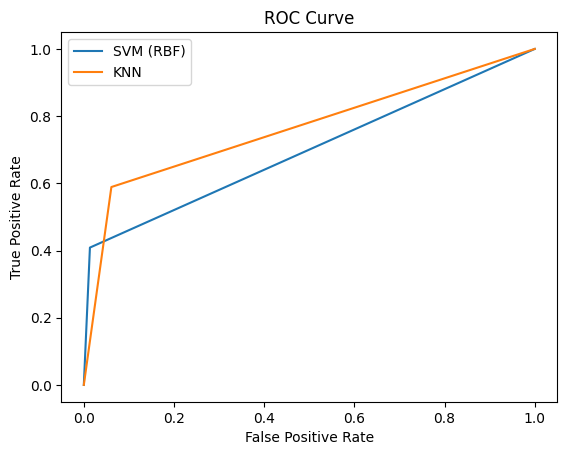

In [33]:
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_pred_svm)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_pred_knn)

plt.plot(fpr_svm, tpr_svm, label="SVM (RBF)")
plt.plot(fpr_knn, tpr_knn, label="KNN")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [34]:
from sklearn.svm import SVC
from sklearn.metrics import f1_score

In [35]:
f1 = f1_score(y_test, y_pred_svm)

print("F1 Score (SVM RBF):", f1)

F1 Score (SVM RBF): 0.5635777904112185


In [36]:
from sklearn.metrics import accuracy_score, precision_score, f1_score
import pandas as pd

In [37]:
y_pred_svm = svm_model.predict(X_test)

y_pred_knn = knn_model.predict(X_test)

In [38]:
svm_acc = accuracy_score(y_test, y_pred_svm)
svm_prec = precision_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm)

knn_acc = accuracy_score(y_test, y_pred_knn)
knn_prec = precision_score(y_test, y_pred_knn)
knn_f1 = f1_score(y_test, y_pred_knn)

In [39]:
results = pd.DataFrame({
    "Model": ["SVM (Linear)", "KNN"],
    "Accuracy": [svm_acc, knn_acc],
    "Precision": [svm_prec, knn_prec],
    "F1 Score": [svm_f1, knn_f1]
})


In [40]:
results

,Model,Accuracy,Precision,F1 Score
0,SVM (Linear),0.931235,0.916640,0.849147
1,KNN,0.853277,0.757483,0.662680
